# Classification

Output Layer Activation: binary(0,1) -> sigmoid ,   binary(-1,1) -> tanh ,   multiclass -> softmax   

Hidden Layer Activation: Relu 

LossFunction -> binary cross entropy (BCE), BCEWithlogit (has built-in sigmoid), cross entropy(for non-binary)

How to get label in binary classification -> round the sigmoid of the logits

How to get label in multi-class classification -> argmax of softmax of the logits

Optimiser -> SGD and Adam

In [125]:
import torch
import sklearn
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [126]:
X,y = sklearn.datasets.make_moons(n_samples=1000 , shuffle=True, noise=0.3, random_state=42)

In [127]:
X.shape, y.shape

((1000, 2), (1000,))

In [128]:
df = pd.DataFrame({"X[1]":X[:,0],"X[2]":X[:,1],"y":y[:]})
df.head(10)

,X[1],X[2],y
0,-0.171863,0.596249,1
1,1.253283,-0.265414,1
2,0.723224,0.231943,1
3,-0.065198,-0.655194,1
4,-0.799493,0.552935,0
5,0.711314,0.073658,1
6,0.262525,-0.178531,1
7,-0.175007,0.594745,1
8,1.540521,-0.367353,1
9,0.818338,1.065851,0


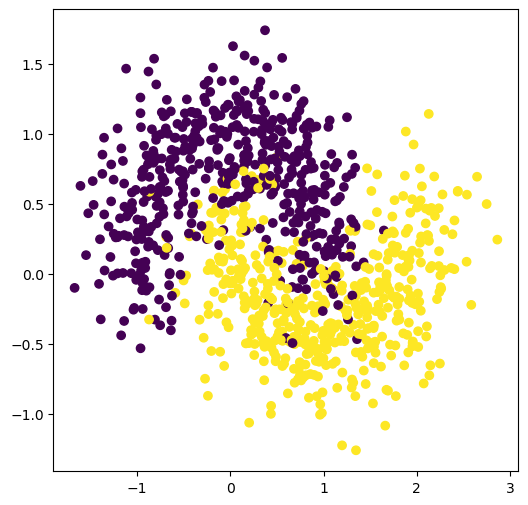

In [129]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0],X[:,1],c=y)

In [130]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X,y,test_size=0.2, shuffle=True,random_state=42)


Text(0.5, 1.0, 'Test data')

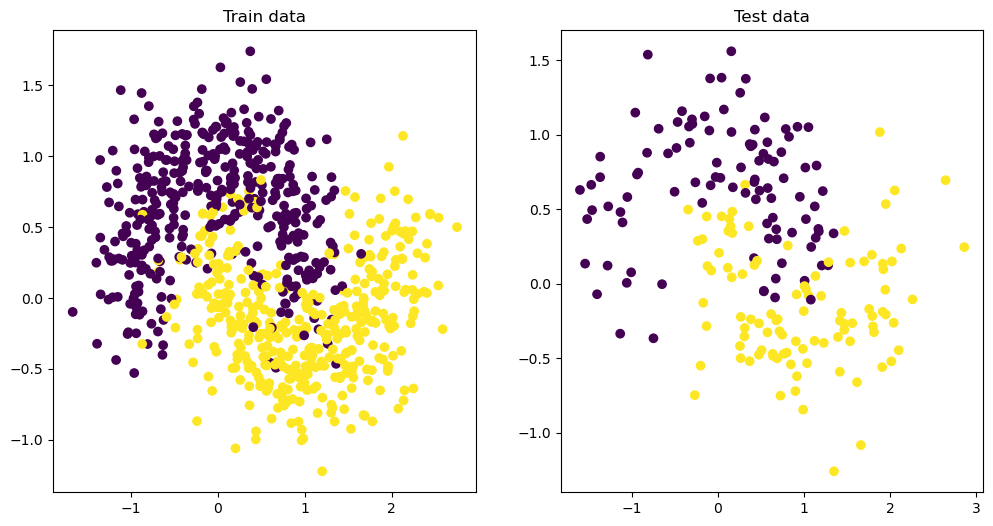

In [131]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
plt.title("Train data")
plt.subplot(1,2,2)
plt.scatter(X_test[:,0],X_test[:,1],c=y_test)
plt.title("Test data")

In [132]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1 = nn.Linear(2,32)
        self.Layer2 = nn.Linear(32,32)
        self.Layer3 = nn.Linear(32,32)
        self.Layer4 = nn.Linear(32,1)
        self.Relu = nn.ReLU()

    def forward(self,X):
        return self.Layer4(self.Relu(self.Layer3(self.Relu(self.Layer2(self.Relu(self.Layer1(X)))))))


device = "cuda" if torch.cuda.is_available() else "cpu"
MyModel = Model().to(device)
device

'cuda'

In [133]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=MyModel.parameters(), lr=0.01)

In [144]:
epochs = 2000
torch.manual_seed(42)
torch.cuda.manual_seed(42)
for epoch in range(epochs):
    MyModel.train()
    y_pred = MyModel(X_train)
    loss = loss_fn(y_pred.squeeze(),y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    MyModel.eval()
    with torch.inference_mode():
        y_pred_test = MyModel(X_test)
        test_loss = loss_fn(y_pred_test.squeeze(),y_test)
        if epoch%100==0:
            print(f"epoch={epoch}, train_loss={loss}, test_loss={test_loss}")

epoch=0, train_loss=0.20428283512592316, test_loss=0.1819288730621338
epoch=100, train_loss=0.20382322371006012, test_loss=0.18122626841068268
epoch=200, train_loss=0.20340217649936676, test_loss=0.18057525157928467
epoch=300, train_loss=0.20301368832588196, test_loss=0.1799817979335785
epoch=400, train_loss=0.2026577591896057, test_loss=0.17941530048847198
epoch=500, train_loss=0.20234863460063934, test_loss=0.1788763701915741
epoch=600, train_loss=0.20206311345100403, test_loss=0.17837102711200714
epoch=700, train_loss=0.2018059343099594, test_loss=0.17790481448173523
epoch=800, train_loss=0.20157413184642792, test_loss=0.17750926315784454
epoch=900, train_loss=0.2013619989156723, test_loss=0.17714618146419525
epoch=1000, train_loss=0.20116427540779114, test_loss=0.17679943144321442
epoch=1100, train_loss=0.20097869634628296, test_loss=0.17648011445999146
epoch=1200, train_loss=0.20080405473709106, test_loss=0.17620062828063965
epoch=1300, train_loss=0.20063965022563934, test_loss=0.

In [145]:
MyModel.eval()
with torch.inference_mode():
    y_test_pred = MyModel(X_test[:10])
    y_test_pred = torch.round(torch.sigmoid(y_test_pred))
    
print(y_test_pred.T)
print(y_test[:10])

tensor([[1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]], device='cuda:0')
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0')
